# Breast Cancer Classification Using Machine Learning

## Objective
To classify breast cancer tumors as Benign or Malignant using Machine Learning.

## Dataset
Wisconsin Diagnostic Breast Cancer Dataset (WDBC)

## Algorithm
Random Forest Classifier

## Goal
Predict whether a tumor is cancerous or non-cancerous.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv("wdbc.data", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
print("Shape of Dataset:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum().sum())

Shape of Dataset: (569, 32)

First 5 Rows:
         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0

In [5]:
X = df.iloc[:, 2:]
y = df.iloc[:, 1]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


In [6]:
le = LabelEncoder()

y = le.fit_transform(y)

print("Classes:", le.classes_)
print(y[:10])

Classes: ['B' 'M']
[1 1 1 1 1 1 1 1 1 1]


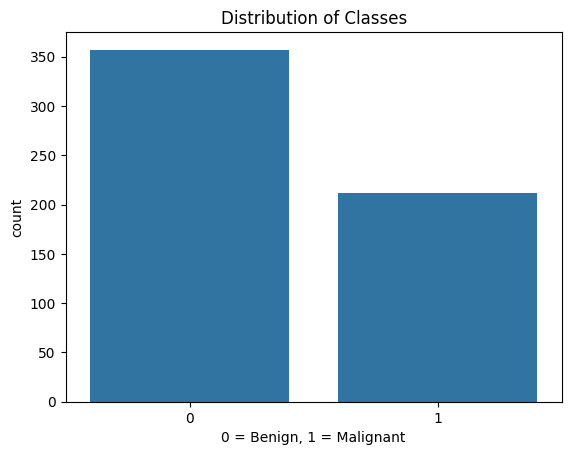

In [7]:
sns.countplot(x=y)

plt.title("Distribution of Classes")
plt.xlabel("0 = Benign, 1 = Malignant")

plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 455
Testing Samples: 114


In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [10]:
predictions = model.predict(X_test)


print(predictions[:10])

[0 1 1 0 0 1 1 1 1 0]


In [11]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 96.49 %


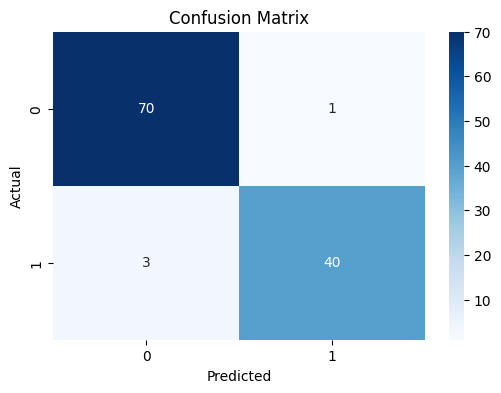

In [12]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [13]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



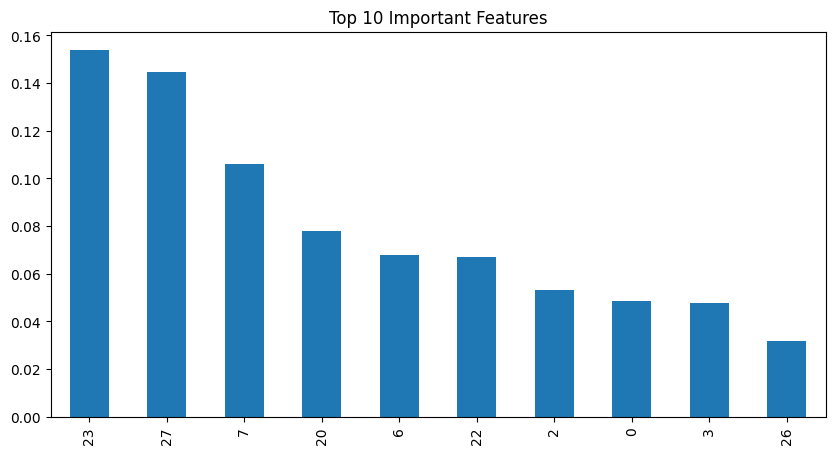

In [14]:
importance = pd.Series(
    model.feature_importances_
)

importance.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [15]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Malignant")
else:
    print("Benign")

Benign


# Conclusion

The Random Forest model successfully classified breast cancer tumors into benign and malignant categories.

## Accuracy Achieved
(Add your accuracy here)

## Result
The model achieved high classification accuracy and demonstrated the effectiveness of machine learning in medical diagnosis.

## Future Improvements
- Hyperparameter tuning
- Deep Learning models
- Web application deployment using Streamlit